## Mean-Shift Algorithm

**Mean-shift algorithm** is a non-parametric, density-based clustering algorithm that finds clusters by seeking modes (peaks) in data’s probability density function
- it works by assigning each data point a cluster based on density of data points in data space, also known as mode in a distribution function
- contrary to k-means, mean-shift algorithm does not require you to specify number of clusters as a parameter
- this algorithm works by modeling data points as a distribution function, where high-density areas (high concentration of data points) represent high peaks
- general idea is to shift each data point until it reaches its nearest peak, which becomes a cluster

**Understand this algorithm**
- 1st step is representation of data points as a density distribution
	- to do this, algorithm builds upon idea of kernel density estimation (**KDE**), which is a method used to estimate distribution of data
	- in figure below, red dots represent input data points, colored lines represent estimated distribution of data points
	- peaks (high-density areas) will be clusters
	- process of assigning data points to each cluster is
		- 1. a window of a specified size (bandwidth) is drawn around each data point
		- 2. mean of data inside window is computed
		- 3. center of window is shifted to mean
- 2nd and 3rd steps are repeated until data point reaches a peak, which will determine cluster to which it belongs.

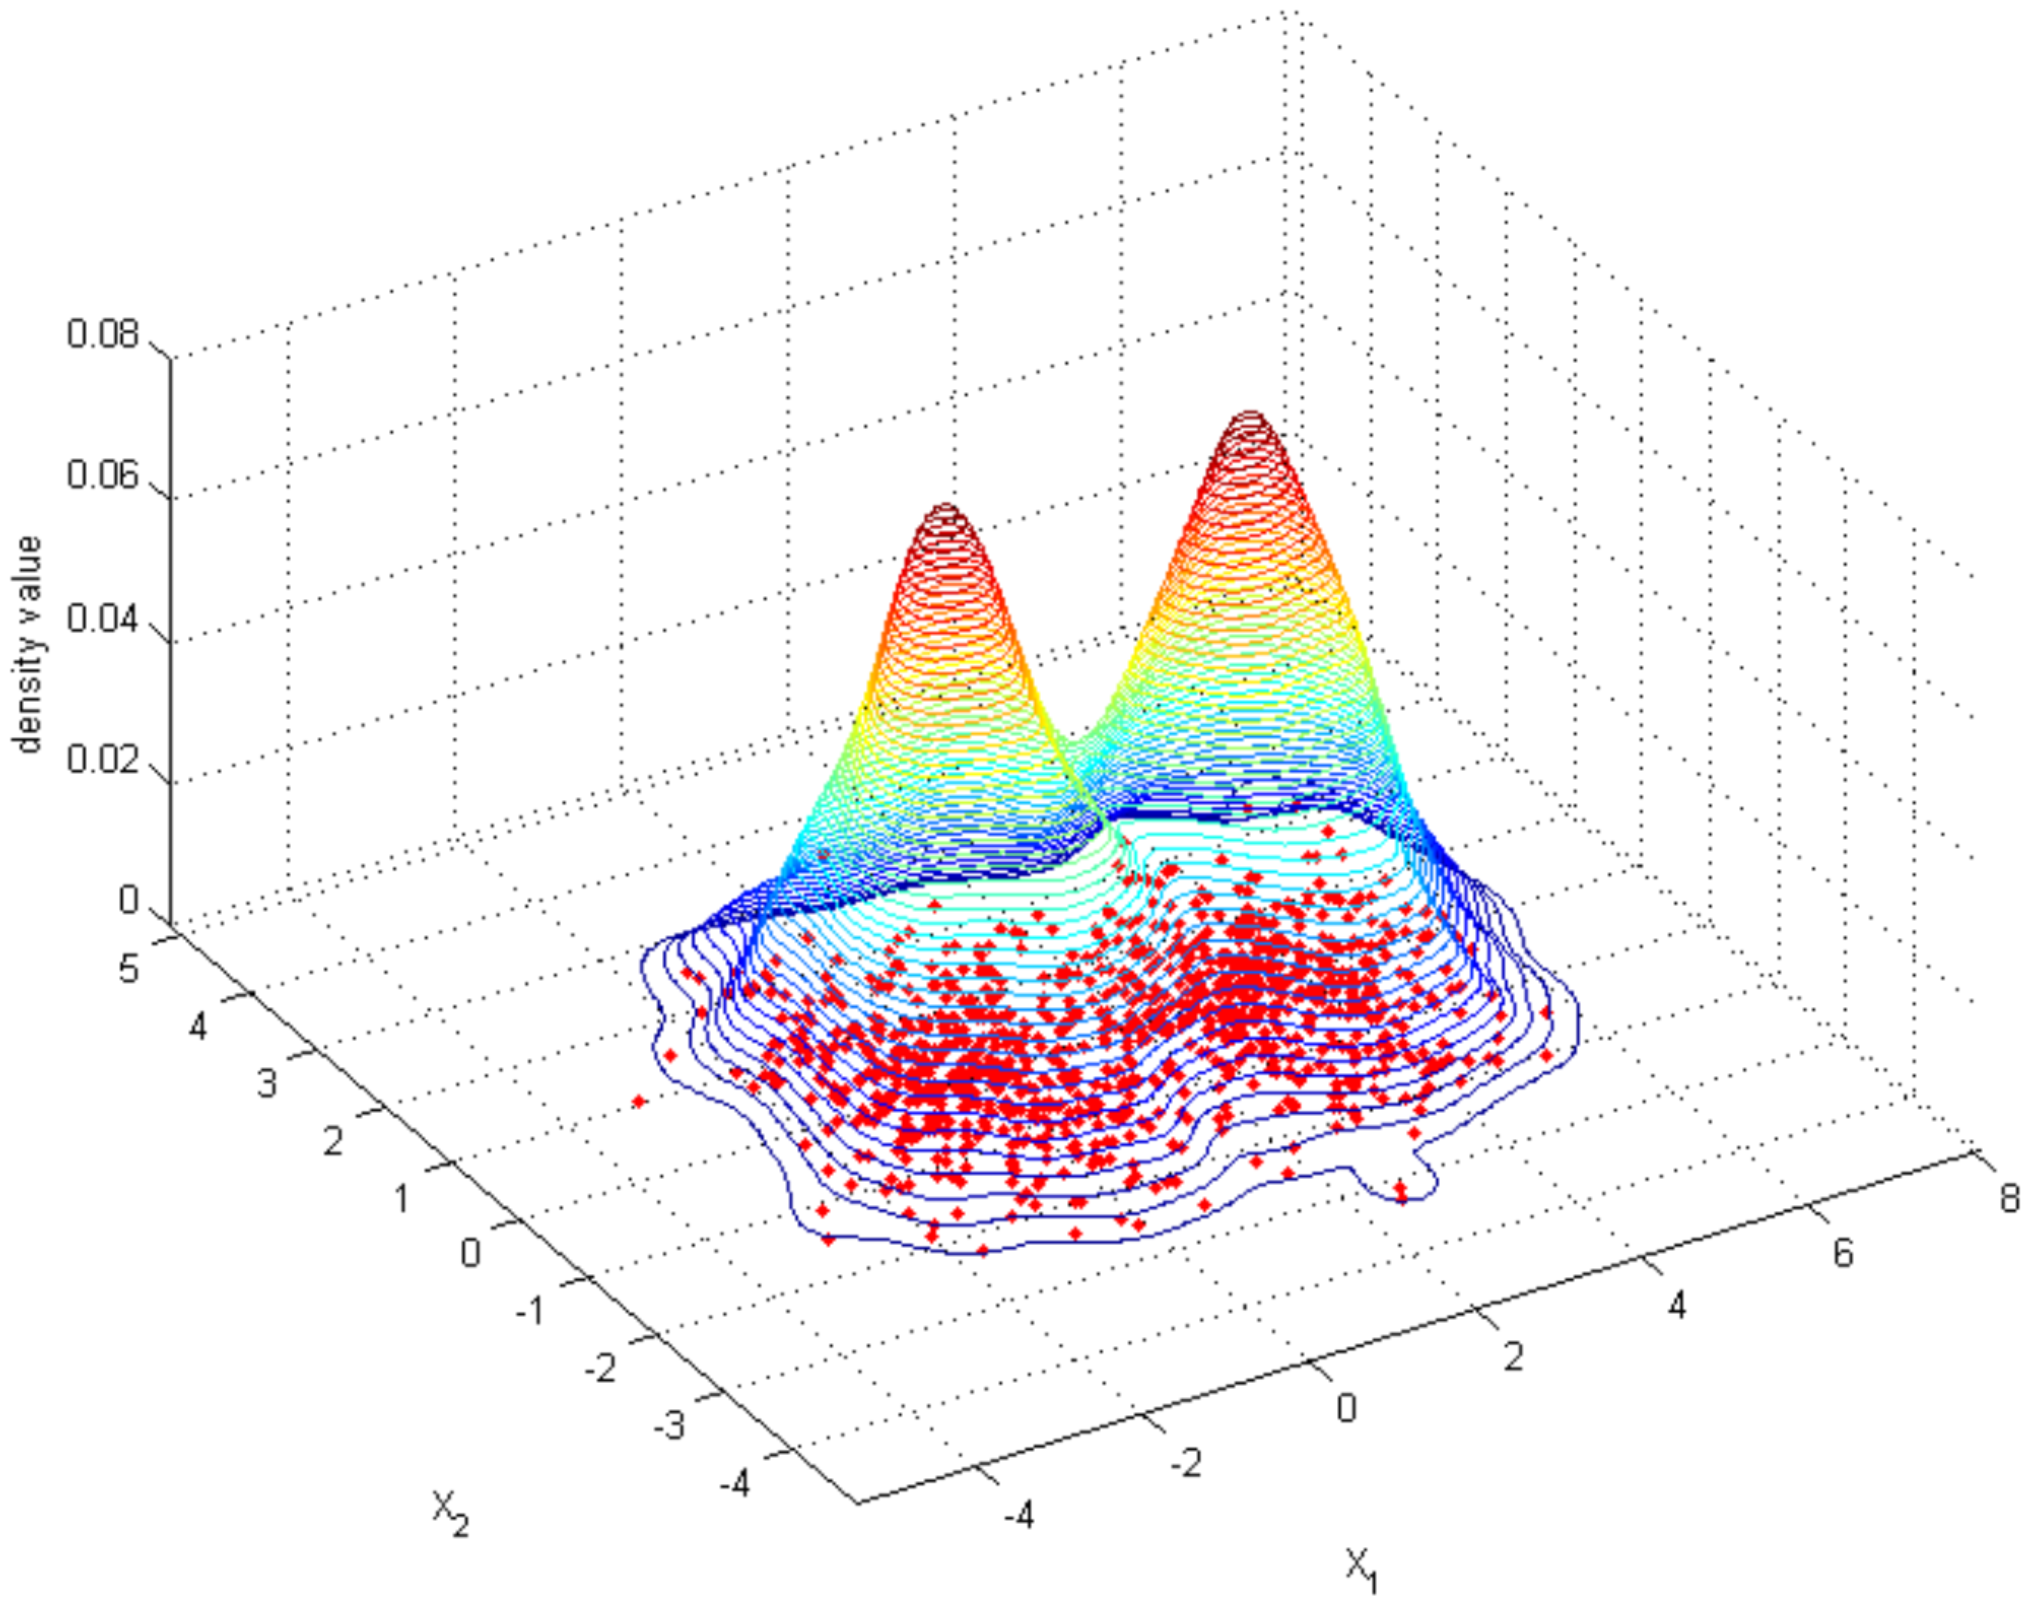

In [3]:
from IPython.display import display, Image
display(Image('./fig-02-10.png', width=1024))

*Figure: An image depicting the idea behind Kernel Density Estimation*.

Imagine each data point lives in a landscape where height = data density.
- Mean Shift moves points uphill
- Each point repeatedly shifts toward the local mean of nearby points
- Points that end up at the same peak belong to the same cluster

Key properties
✅ Advantages
No need to specify number of clusters
Can find arbitrarily shaped clusters
Naturally finds cluster centers (modes)
Works well when clusters are well separated in density

❌ Disadvantages

Computationally expensive: O(n^2)
Very sensitive to bandwidth selection
Struggles with high-dimensional data
Poor performance on large datasets without approximations


Mean Shift vs DBSCAN:
DBSCAN finds connected dense regions
Mean Shift finds density peaks (modes)

Bandwidth value should be coherent with distribution of data points in dataset
- *i.e.*, for a dataset normalized between 0 and 1, bandwidth value should be within that range, while for a dataset with all values between 1000 and 2000, it would make more sense to have a bandwidth between 100 and 500
- in following diagram, estimated distribution is represented by lines, and data points are red dots
	- in each box, data points shift to nearest peak
	- all data points in a certain peak belong to that cluster
	- number of shifts that a data point has to make to reach a peak depends on its bandwidth (size of window) and its distance from peak.

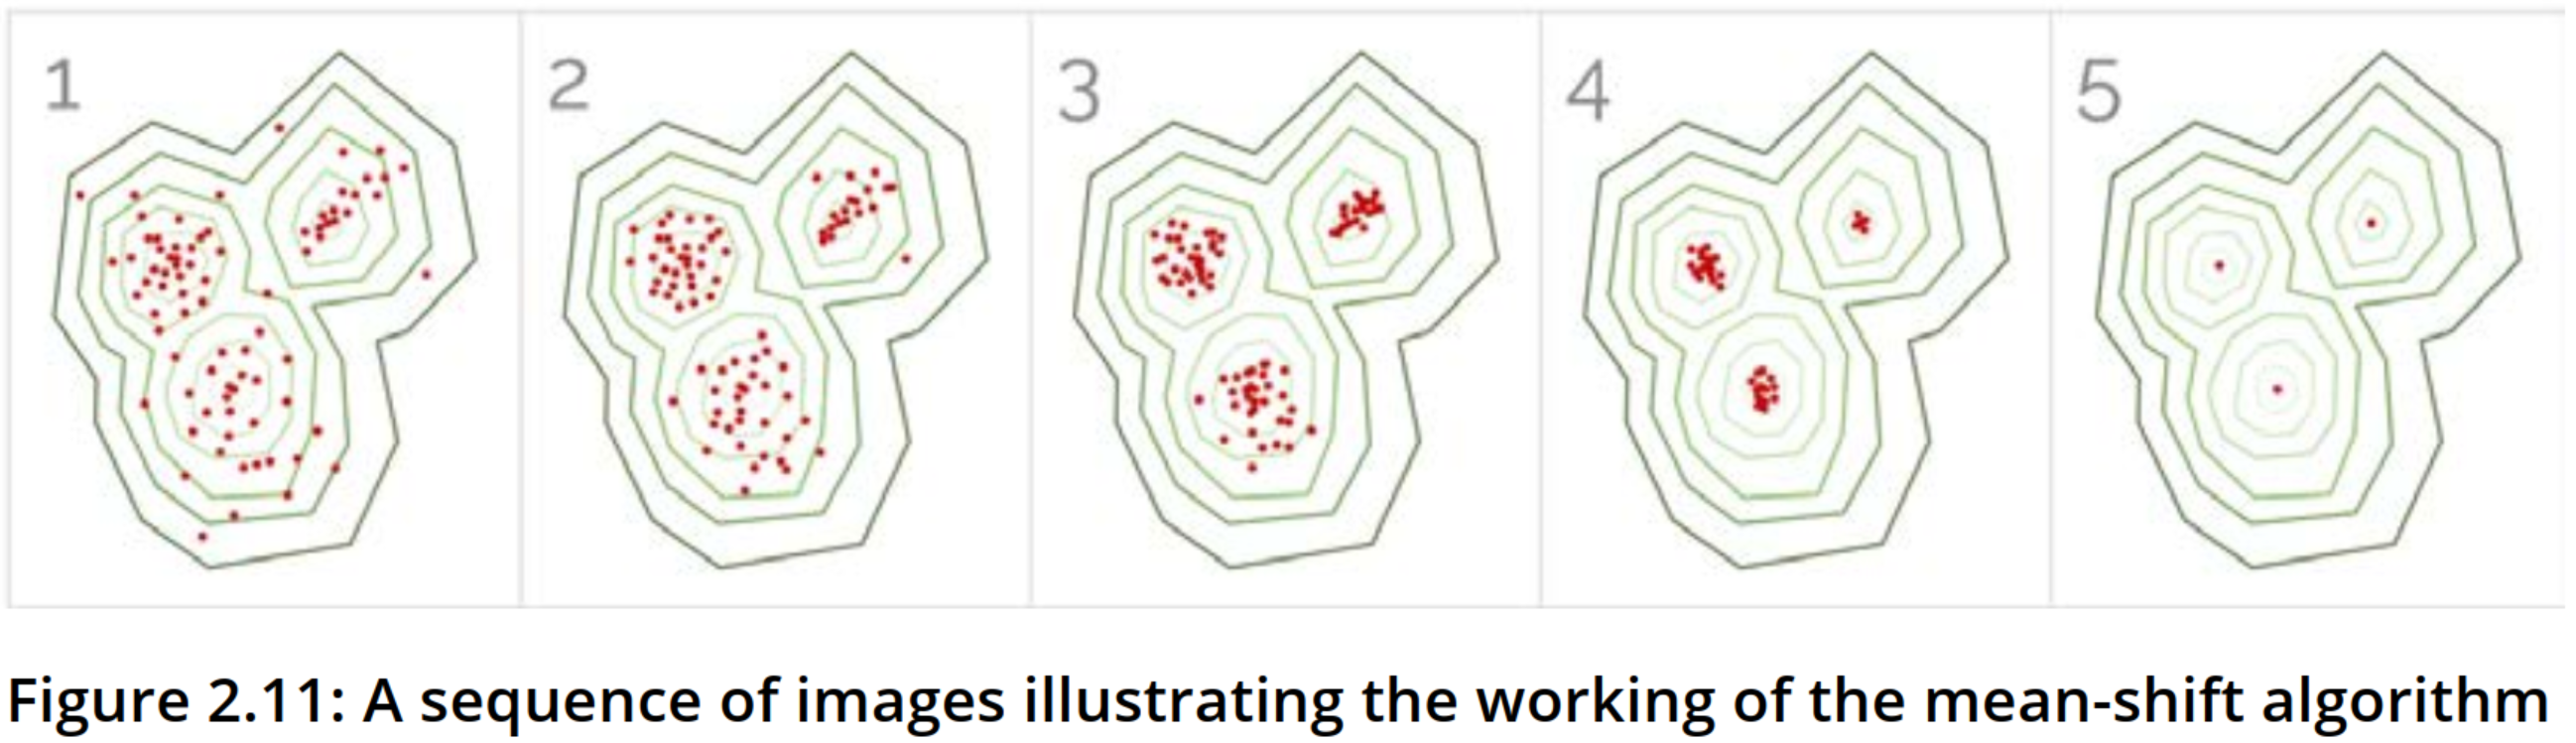

In [4]:
from IPython.display import display, Image
display(Image('./fig-02-11.png', width=1024))

Figure: *A sequence of images illustrating working of mean-shift algorithm*.

In [ ]:
from sklearn.cluster import MeanShift

# train model with a bandwidth of 0.5
est_meanshift = MeanShift(0.5)
est_meanshift.fit(data)
pred_meanshift = est_meanshift.predict(data)

plt.scatter(data[:,0], data[:,1], c=pred_meanshift)
plt.show()

In [ ]:
from sklearn.cluster import MeanShift, estimate_bandwidth

bandwidth = estimate_bandwidth(X, quantile=0.2)
ms = MeanShift(bandwidth=bandwidth)
ms.fit(X)

labels = ms.labels_
cluster_centers = ms.cluster_centers_